## Exploratory Data Analysis On Google PlayStore User Dataset

## Import the Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# display rows and columns
pd.set_option('display.max_columns', None) # None --> All Columns
pd.set_option('display.max_rows', 1000)

## DataSet Two Loading - user reviews.csv

In [3]:
# load the dataset
data = pd.read_csv(r'D:\PlayStore App Review Analysis(EDA Project)\data\unprocessed\User Reviews.csv')

In [5]:
# display the first 5 rows of the dataset
data.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


In [9]:
# no of rows and columns in a dataset
data.shape

(64295, 5)

In [ ]:
# describe the dataset
data.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


### Basic Inspection — Observations

- The User Review dataset contains **64,295 records and 5 columns**.
- The dataset includes information about the **app name, translated user reviews, sentiment, sentiment polarity, and sentiment subjectivity**.
- The `App` column contains **64,295 non-null values**, while the remaining four columns contain **37,432 non-null values**, indicating a substantial number of missing values that require further investigation.
- The `Sentiment` and `Translated_Review` columns are stored as **string (`str`) data types**, while `Sentiment_Polarity` and `Sentiment_Subjectivity` are stored as **floating-point (`float64`) values**.
- `Sentiment_Polarity` ranges from **-1 to 1**, with a mean of approximately **0.18**, suggesting that the reviews have a generally **slightly positive sentiment**.
- `Sentiment_Subjectivity` ranges from **0 to 1**, with a mean of approximately **0.49**, indicating a **moderate level of subjectivity** in the reviews.
- The numerical columns appear to have valid ranges based on their definitions, but their distributions and potential outliers will require further investigation.

## Check for Null Values

In [11]:
# check for total null values in the datset
data.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

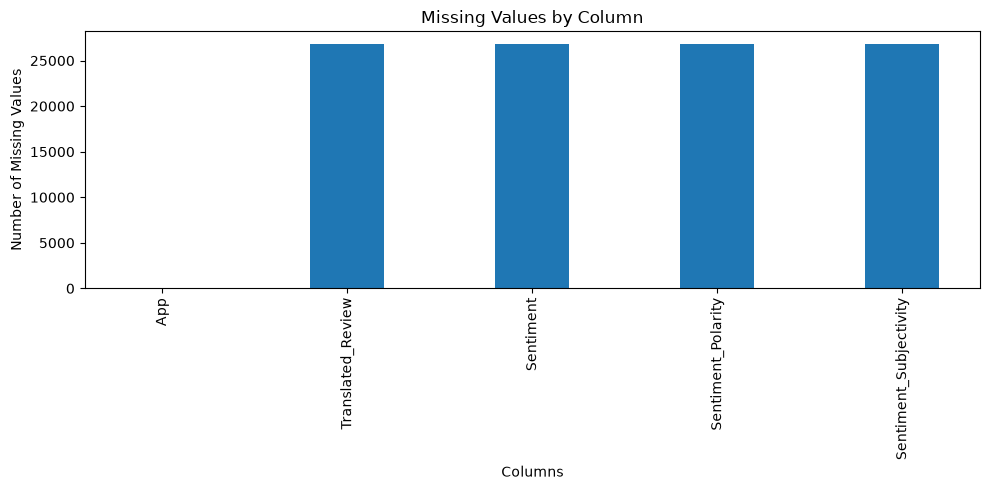

In [12]:
# Visualizing the missing values
missing_values = data.isnull().sum()

plt.figure(figsize=(10, 5))
plt.bar(missing_values.index, missing_values.values, width=0.4)
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values by Column')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
# Check the percentage of null values in each column
data.isnull().sum() / len(data) * 100

App                        0.000000
Translated_Review         41.788631
Sentiment                 41.780854
Sentiment_Polarity        41.780854
Sentiment_Subjectivity    41.780854
dtype: float64

In [14]:
# checking for null values in Translated_Review column
data[data['Translated_Review'].isnull()].head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
2,10 Best Foods for You,NaN,NaN,NaN,NaN
7,10 Best Foods for You,NaN,NaN,NaN,NaN
15,10 Best Foods for You,NaN,NaN,NaN,NaN
102,10 Best Foods for You,NaN,NaN,NaN,NaN
107,10 Best Foods for You,NaN,NaN,NaN,NaN
115,10 Best Foods for You,NaN,NaN,NaN,NaN
268,11st,NaN,Neutral,0.0,0.0
362,1LINE – One Line with One Touch,NaN,NaN,NaN,NaN
368,1LINE – One Line with One Touch,NaN,NaN,NaN,NaN
405,2018Emoji Keyboard 😂 Emoticons Lite -sticker&gif,NaN,NaN,NaN,NaN


## Observation

- The missing values in `Translated_Review` are generally accompanied by missing values in the corresponding sentiment-related columns.
- This suggests that these records likely represent **apps for which no translated review information is available** in the dataset.
- The missing values therefore appear to be related to the **absence of review data**, rather than random missing entries.
- However, a small number of records contain sentiment information even when `Translated_Review` is missing, so the missingness is not perfectly identical across all records.
- Since `Translated_Review`, `Sentiment`, `Sentiment_Polarity`, and `Sentiment_Subjectivity` are the core review-analysis fields, these records require further consideration before deciding whether to remove them.

In [ ]:
# check total no of rows have all four columns('Translated_Review', 'Sentiment', 'Sentiment_Polarity') null values
data[data[['Translated_Review', 'Sentiment', 'Sentiment_Polarity']].isnull().all(axis=1)].shape[0]

26863

In [16]:
# droping the rows which have all four columns('Translated_Review', 'Sentiment', 'Sentiment_Polarity') null values
data = data.dropna(subset=['Translated_Review', 'Sentiment', 'Sentiment_Polarity'], how='all')

In [17]:
data.isnull().sum()

App                       0
Translated_Review         5
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 37432 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     37432 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.7 MB


In [19]:
data.shape

(37432, 5)

### Null Value Analysis — Final Observation

- The `App` column contains **no missing values**, while the review and sentiment-related columns initially contained approximately **41.78% missing values**.
- `Translated_Review`, `Sentiment`, `Sentiment_Polarity`, and `Sentiment_Subjectivity` had almost identical missing-value percentages, indicating that the missingness was primarily associated with records where **review information was unavailable**.
- Further investigation showed that **26,863 records had all four review-related fields missing**. Since these records contained no usable review or sentiment information, they were removed from the dataset.
- After removing these records, only **5 missing values remain in `Translated_Review`**.
- These 5 records were retained because their corresponding `Sentiment`, `Sentiment_Polarity`, and `Sentiment_Subjectivity` values are available and can still contribute to sentiment analysis.
- The remaining missing review texts will be **left as missing rather than artificially imputed**, since the original review content cannot be reliably reconstructed.
- Overall, the missing-value treatment preserves records containing useful sentiment information while removing records that had **no usable review or sentiment data**.

## Check For Duplicate Values

In [21]:
# check for duplicated rows in the dataset
data.duplicated().sum()

np.int64(7735)

In [25]:
# display all the duplicated rows in the dataset
data_duplicated =  data[data['App'].duplicated(keep=False)]
data_duplicated.sort_values(by='App').head(20)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
130,10 Best Foods for You,Good.!!,Positive,1.000000,0.600000
131,10 Best Foods for You,Thanks advice. Downloaded Adobe reader still c...,Positive,0.200000,0.200000
132,10 Best Foods for You,No recipe book Unable recipe book.,Negative,-0.500000,0.500000
133,10 Best Foods for You,Absolutely Fabulous Phenomenal,Positive,0.450000,0.750000
134,10 Best Foods for You,Great Love food,Positive,0.650000,0.675000
135,10 Best Foods for You,Excellent It really works,Positive,0.600000,0.600000
136,10 Best Foods for You,Best,Positive,1.000000,0.300000
137,10 Best Foods for You,WEALTH OF INFORMATION Very informative ... eas...,Positive,0.186616,0.356313
138,10 Best Foods for You,Not description good,Positive,0.700000,0.600000


In [26]:
# droping the duplicated identical rows in the dataset
data = data.drop_duplicates(keep='first')

In [27]:
# check for duplicated rows in the dataset after dropping the duplicated identical rows
data.duplicated().sum()

np.int64(0)

### Duplicate Analysis — Observation

- The dataset contains a large number of **genuine user reviews**, where the same app can have multiple different reviews.
- A total of **7,735 exact duplicate row occurrences** were identified, where the complete user review record was repeated with identical values across all columns.
- These duplicate records do not provide any additional information and are therefore **redundant**.
- The exact duplicate records were removed while preserving different user reviews belonging to the same application.

In [28]:
data.info()

<class 'pandas.DataFrame'>
Index: 29697 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29697 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29697 non-null  str    
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.4 MB


## Outlier Analysis

In [31]:
# check for outliers with the IQR method for Sentiment_Polarity column
Q1 = data['Sentiment_Polarity'].quantile(0.25)
Q3 = data['Sentiment_Polarity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
print(lower_bound)
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)

outliers = data[(data['Sentiment_Polarity'] < lower_bound) | (data['Sentiment_Polarity'] > upper_bound)]

print("Number of outliers:", len(outliers))

-0.63375
1.05625
Number of outliers: 587


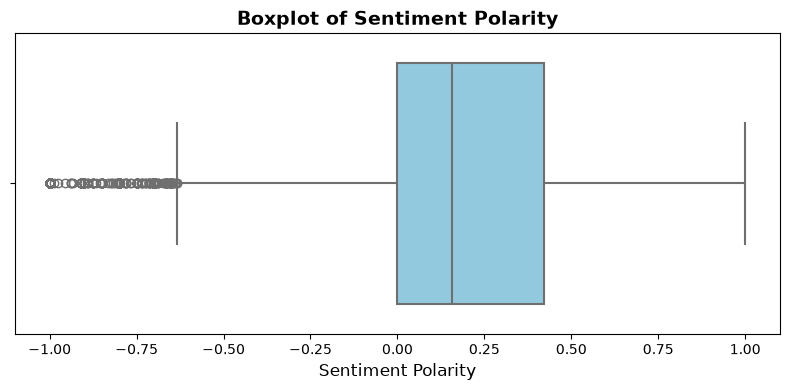

In [32]:
# plotiing the outliers in sentiment_polarity to visualize the spread of outliers
plt.figure(figsize=(8, 4))

sns.boxplot(x=data['Sentiment_Polarity'], color='skyblue', linewidth=1.5)

plt.title("Boxplot of Sentiment Polarity", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Polarity", fontsize=12)

plt.tight_layout()
plt.show()

### Sentiment Polarity — Outlier Analysis Observation

- A total of **587 outliers** were identified in `Sentiment_Polarity`, all occurring on the **lower side of the distribution**.
- These observations represent reviews with relatively low or negative sentiment polarity.
- Since `Sentiment_Polarity` legitimately ranges from **-1 (strongly negative) to +1 (strongly positive)**, these values are not necessarily data errors.
- The lower-end outliers can represent **genuine negative user feedback** and therefore provide meaningful information for sentiment analysis.
- Hence, the identified outliers will be **retained** rather than removed.

In [33]:
# check for outliers with the IQR method for Sentiment_Subjectivity column
Q1 = data['Sentiment_Subjectivity'].quantile(0.25)
Q3 = data['Sentiment_Subjectivity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
print(lower_bound)
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)

outliers = data[(data['Sentiment_Subjectivity'] < lower_bound) | (data['Sentiment_Subjectivity'] > upper_bound)]

print("Number of outliers:", len(outliers))

-0.10375000000000018
1.1062500000000002
Number of outliers: 0


### Sentiment Subjectivity — Outlier Analysis

- The IQR method identified **no outliers** in `Sentiment_Subjectivity`.
- The calculated lower and upper bounds are approximately **-0.104 and 1.107**, respectively.
- All observed subjectivity values fall within these bounds, indicating that there are **no statistically unusual observations** according to the IQR method.
- Therefore, no outlier treatment or removal is required for `Sentiment_Subjectivity`.

## Final Sanity Checks

In [34]:
# checking the data shape
data.shape

(29697, 5)

In [35]:
# check for any remaining null values
data.isnull().sum()

App                       0
Translated_Review         5
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [36]:
# final check for duplicate rows
data.duplicated().sum()

np.int64(0)

In [37]:
# check for sentiment categories
data['Sentiment'].value_counts()

Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64

In [38]:
# check for the range of polarity
data['Sentiment_Polarity'].min(), data['Sentiment_Polarity'].max()

(np.float64(-1.0), np.float64(1.0))

In [39]:
data[
    (data['Sentiment_Polarity'] < -1) |
    (data['Sentiment_Polarity'] > 1)
].shape[0]

0

In [40]:
# check for range of subjectivity
data['Sentiment_Subjectivity'].min(), data['Sentiment_Subjectivity'].max

(np.float64(0.0),
 <bound method Series.max of 0        0.533333
 1        0.288462
 3        0.875000
 4        0.300000
 5        0.300000
            ...   
 64222    0.486667
 64223    0.447222
 64226    0.250000
 64227    1.000000
 64230    0.400000
 Name: Sentiment_Subjectivity, Length: 29697, dtype: float64>)

In [41]:
data[
    (data['Sentiment_Subjectivity'] < 0) |
    (data['Sentiment_Subjectivity'] > 1)
].shape[0]

0

In [43]:
# final data info check
data.info()

<class 'pandas.DataFrame'>
Index: 29697 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29697 non-null  str    
 1   Translated_Review       29692 non-null  str    
 2   Sentiment               29697 non-null  str    
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.4 MB


### Final Sanity Check — Observation

- After the data-cleaning process, the dataset contains **29,697 records and 5 columns**.
- No duplicate rows remain after removing the **7,735 exact duplicate row occurrences**.
- The `App`, `Sentiment`, `Sentiment_Polarity`, and `Sentiment_Subjectivity` columns contain **no missing values**.
- Only **5 missing values remain in `Translated_Review`**, while the corresponding sentiment information is available, so these records have been retained.
- `Sentiment_Polarity` values remain within their valid range of **-1 to 1**, and `Sentiment_Subjectivity` values remain within **0 to 1**.
- The data types of all columns are appropriate for further analysis.
- Overall, the dataset has passed the final sanity checks and is **ready for exploratory visualization and analysis**.

## Data Visualization

# Univariate Analysis

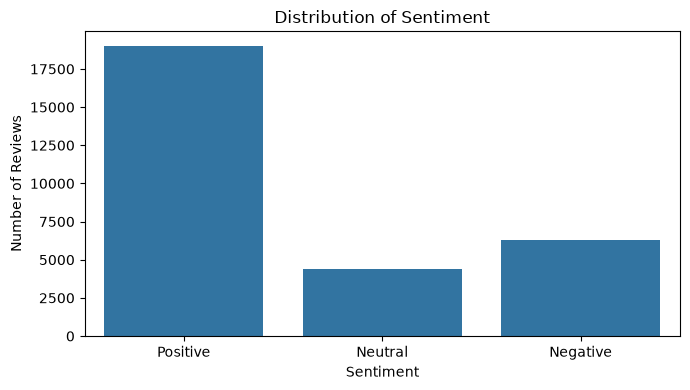

In [44]:
# Distribution of Sentiment Categories
plt.figure(figsize=(7, 4))

sns.countplot(
    data=data,
    x='Sentiment'
)

plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Distribution

- **Positive reviews have the highest representation**, with approximately **17,500 reviews**.
- **Negative reviews are the second most common**, with approximately **6,000–6,500 reviews**.
- **Neutral reviews have the lowest representation**, with fewer than **5,000 reviews**.
- There is a **substantial difference between positive and negative reviews**, with positive reviews considerably outnumbering negative reviews.
- Overall, the distribution indicates that **user reviews are predominantly positive**, while neutral reviews form the smallest sentiment group.


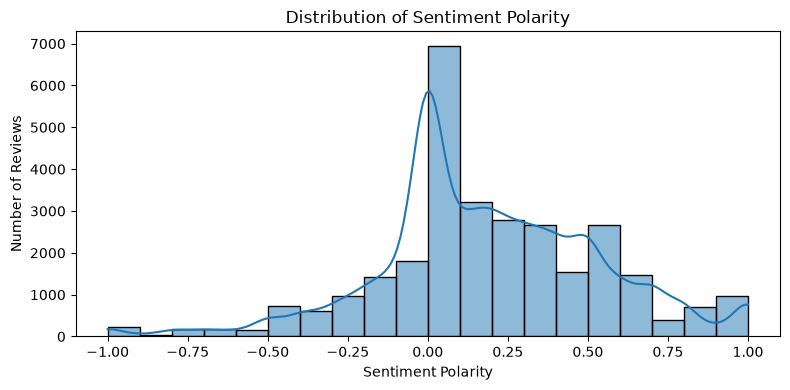

In [45]:
# Distribution of Sentiment Polarity
plt.figure(figsize=(8, 4))

sns.histplot(
    data=data,
    x='Sentiment_Polarity',
    bins=20,
    kde=True
)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Polarity Distribution

- The distribution is **slightly left-skewed**, with a longer tail extending toward negative polarity values.
- Most reviews have **positive sentiment polarity**, with the highest concentration of reviews occurring around **0 to 0.2**.
- The frequency of reviews is considerably higher around the **neutral-to-positive range** than at strongly negative polarity values.
- Strongly negative polarity values have relatively **low representation**, while positive polarity values are more widely represented.
- Overall, the distribution supports the earlier finding that **positive sentiment dominates the user reviews** in this dataset.

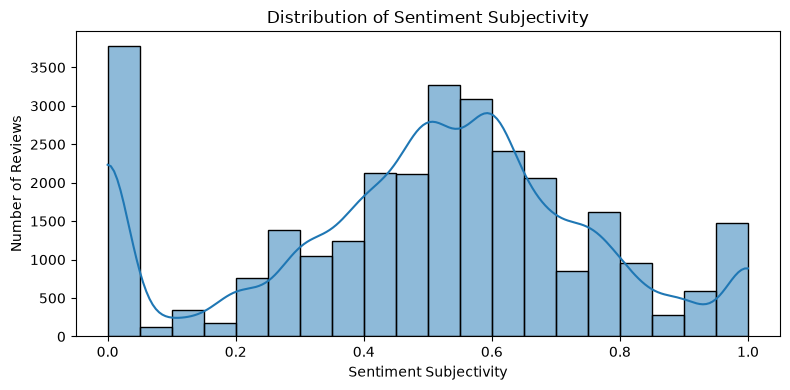

In [46]:
# Distribution of Sentiment Subjectivity
plt.figure(figsize=(8, 4))

sns.histplot(
    data=data,
    x='Sentiment_Subjectivity',
    bins=20,
    kde=True
)

plt.title('Distribution of Sentiment Subjectivity')
plt.xlabel('Sentiment Subjectivity')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Subjectivity Distribution

- The reviews show a **wide range of subjectivity values**, from 0 to 1.
- A substantial number of reviews are concentrated in the **0.4–0.7 range**, indicating a moderate to relatively high level of subjectivity.
- The highest concentration is around **0.5–0.6**, with approximately 3,000+ reviews in these ranges.
- There is also a noticeable number of reviews with subjectivity close to **0**, indicating more objective statements.
- Similarly, a smaller group of reviews has subjectivity close to **1**, representing highly subjective reviews.
- Overall, the distribution suggests that user reviews contain a **mix of objective and subjective statements**, with a considerable proportion showing moderate subjectivity.

# Bivariate Analysis

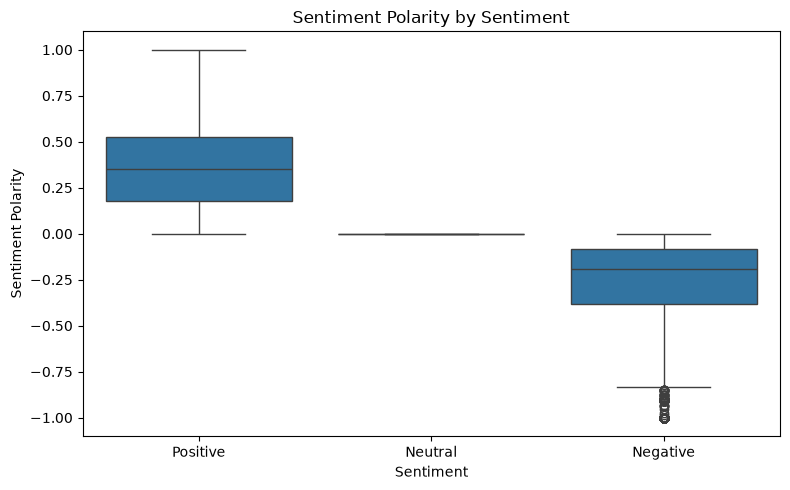

In [47]:
# Sentiment Vs Sentiment Polarity
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Sentiment',
    y='Sentiment_Polarity'
)

plt.title('Sentiment Polarity by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Sentiment Polarity')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Polarity by Sentiment

- **Positive reviews** have polarity values concentrated on the **positive side**, with the median around **0.35**, indicating that their sentiment polarity is predominantly positive.
- **Negative reviews** have polarity values concentrated on the **negative side**, with the median around **-0.20**, indicating predominantly negative sentiment.
- **Neutral reviews** are concentrated around **0 polarity**, which is consistent with their neutral sentiment classification.
- The Negative group contains several **lower-end outliers**, representing reviews with particularly strong negative polarity.
- Overall, the polarity distributions clearly correspond with their respective sentiment categories: **Positive reviews have positive polarity, Negative reviews have negative polarity, and Neutral reviews remain around zero**.

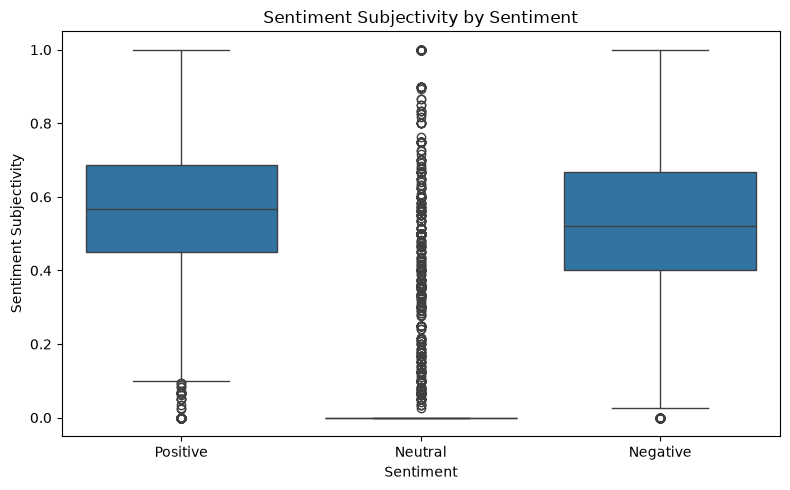

In [48]:
# sentiment vs sentiment subjectivity
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Sentiment',
    y='Sentiment_Subjectivity'
)

plt.title('Sentiment Subjectivity by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Sentiment Subjectivity')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Subjectivity by Sentiment

- **Positive reviews** have their subjectivity values mainly concentrated in the **moderate-to-high range**, with the median around **0.57**. A small number of lower-end outliers are also present.
- **Negative reviews** show a similar pattern, with subjectivity values primarily concentrated between the **moderate and relatively high range**, and a small number of lower-end outliers.
- **Neutral reviews** have their main distribution concentrated around **0**, but show a large number of **upper-side outliers**, extending toward highly subjective values.
- Overall, **Positive and Negative reviews tend to have higher typical subjectivity than Neutral reviews**, while Neutral reviews display a much wider range of subjectivity values due to the numerous upper-end observations.

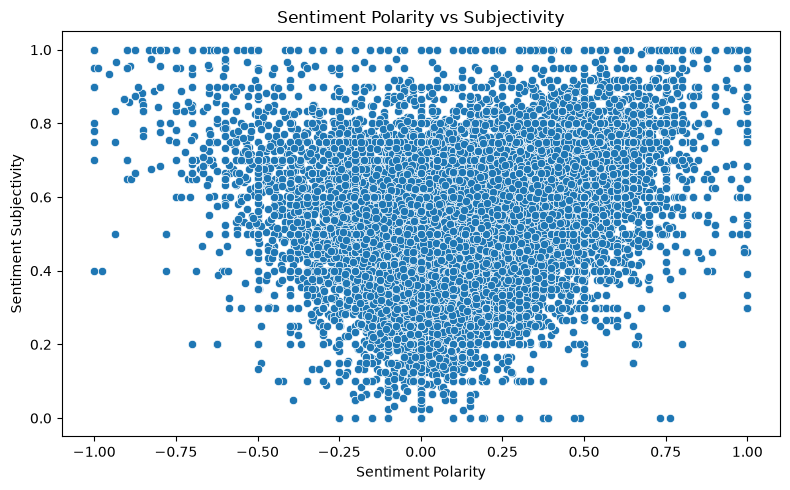

In [49]:
# Polartiy vs Subjectivity
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='Sentiment_Polarity',
    y='Sentiment_Subjectivity'
)

plt.title('Sentiment Polarity vs Subjectivity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Sentiment Subjectivity')

plt.tight_layout()
plt.show()

### Key Insights — Sentiment Polarity vs Subjectivity

- The majority of reviews are concentrated around **neutral to slightly positive polarity values**, particularly between approximately **0 and 0.5**.
- Most reviews have **moderate to relatively high subjectivity**, with a large concentration between approximately **0.4 and 0.8**.
- The highest concentration of observations appears around **neutral-to-positive polarity and moderate subjectivity**.
- The scatter plot shows a **wide spread of points**, indicating that subjectivity varies considerably across different polarity levels.
- Overall, there is **no clearly strong relationship** between sentiment polarity and subjectivity; reviews with similar subjectivity can have negative, neutral, or positive polarity.

# Multivariate Analysis

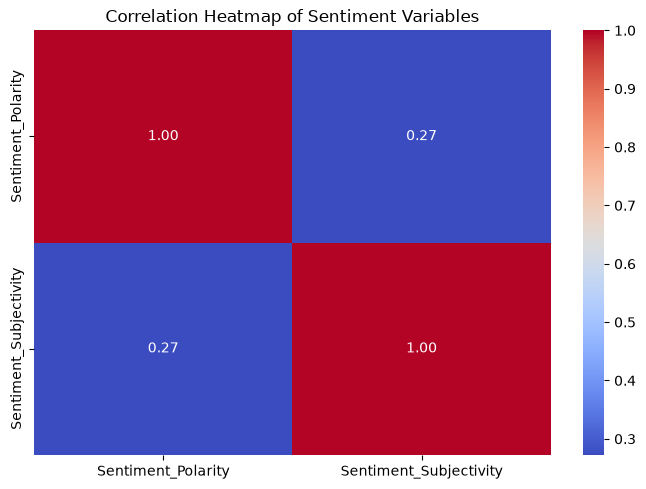

In [50]:
# coorrelation between Sentiment Polarity and Subjectivity
plt.figure(figsize=(7, 5))

corr = data[['Sentiment_Polarity', 'Sentiment_Subjectivity']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Sentiment Variables')

plt.tight_layout()
plt.show()

### Key Insights — Correlation Heatmap

- `Sentiment_Polarity` and `Sentiment_Subjectivity` have a correlation of approximately **0.27**, indicating a **weak positive relationship** between the two variables.
- This suggests that reviews with higher sentiment polarity tend to have **slightly higher subjectivity**, but the relationship is not strong.
- The relatively low correlation indicates that **sentiment polarity and subjectivity are largely independent of each other**, with considerable variation in subjectivity across different polarity values.
- Overall, there is **no strong linear relationship** between sentiment polarity and sentiment subjectivity.

## Final Conclusion — User Review Analysis

- The dataset initially contained a substantial number of missing values and duplicate records. After cleaning, the dataset was reduced to **29,697 records**, with exact duplicate records removed while retaining genuine and distinct user reviews.
- The majority of user reviews are **Positive**, followed by Negative reviews, while Neutral reviews have the lowest representation.
- The sentiment polarity distribution confirms that reviews are predominantly concentrated around **neutral to positive polarity**, with strongly negative reviews representing a smaller proportion of the dataset.
- Sentiment subjectivity is generally concentrated in the **moderate-to-high range**, although the dataset also contains both highly objective and highly subjective reviews.
- The comparison between sentiment and polarity shows a clear consistency: **Positive reviews have positive polarity, Negative reviews have negative polarity, and Neutral reviews are concentrated around zero polarity**.
- Positive and Negative reviews generally show **moderate-to-high subjectivity**, while Neutral reviews display a wider variation in subjectivity.
- The correlation analysis shows a **weak positive relationship (0.27)** between sentiment polarity and subjectivity, indicating that the two variables are only weakly related.
- Overall, the analysis suggests that **users tend to provide predominantly positive feedback**, and the sentiment of a review is strongly reflected in its polarity, while the level of subjectivity varies independently to a large extent.

### Overall Finding

The user review dataset indicates **generally positive user sentiment**, with most reviews expressing positive opinions and moderate-to-high subjectivity. Although negative reviews are less frequent, they provide valuable information about areas of user dissatisfaction. Therefore, both positive and negative reviews should be retained for further analysis rather than treating negative sentiment as an anomaly.

In [51]:
# saving the cleaned dataset to a new CSV file
data.to_csv(r'D:\PlayStore App Review Analysis(EDA Project)\data\processed\Cleaned_User_Reviews.csv', index=False)